In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

Task 1

Loading the dataset 

In [22]:
data, meta = arff.loadarff('lab 6 dataset.arff')
df = pd.DataFrame(data)
df.head()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
0,2.386,3.077,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,38.32,21.32,77.36,92.56,1.740,9.32,25.72
1,2.544,1.972,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,40.20,29.72,77.88,73.56,1.335,10.00,24.76
2,2.807,3.347,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,47.00,21.40,30.80,64.80,1.610,10.60,8.88
3,4.308,1.933,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,43.52,29.72,56.40,90.00,2.150,11.92,22.70
4,4.383,1.081,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,38.52,26.20,66.40,88.40,1.565,16.32,34.32


Summary 

In [23]:
df.describe()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2.963384,2.631769,0.142061,0.228412,0.607242,0.022284,0.211699,0.345404,0.247911,0.016713,0.178273,35.017827,20.018217,54.630975,75.881894,1.288237,9.439086,23.585471
std,0.980822,1.269089,0.349600,0.420396,0.489045,0.147812,0.409083,0.476163,0.432402,0.128373,0.383277,10.662561,8.094140,33.097935,30.818669,0.859098,3.568250,22.267948
min,0.491000,0.524000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.320000,1.980000,18.680000,25.000000,0.135000,1.552000,3.552000
25%,2.260500,1.510500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.640000,14.600000,36.320000,54.600000,0.652500,6.660000,10.470000
50%,3.040000,2.489000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.800000,20.680000,46.800000,73.560000,1.100000,9.840000,17.200000
75%,3.674000,3.652000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,41.460000,25.380000,60.200000,90.000000,1.680000,12.100000,26.920000
max,4.920000,5.690000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,53.200000,300.000000,259.840000,5.129000,20.600000,166.400000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Xloc       359 non-null    float64
 1   Yloc       359 non-null    float64
 2   Landuse_1  359 non-null    float64
 3   Landuse_2  359 non-null    float64
 4   Landuse_3  359 non-null    float64
 5   Landuse_4  359 non-null    float64
 6   Rock_1     359 non-null    float64
 7   Rock_2     359 non-null    float64
 8   Rock_3     359 non-null    float64
 9   Rock_4     359 non-null    float64
 10  Rock_5     359 non-null    float64
 11  Cr         359 non-null    float64
 12  Ni         359 non-null    float64
 13  Pb         359 non-null    float64
 14  Zn         359 non-null    float64
 15  Cd         359 non-null    float64
 16  Co         359 non-null    float64
 17  Cu         359 non-null    float64
dtypes: float64(18)
memory usage: 50.6 KB


In [25]:
df.columns

Index(['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4',
       'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb',
       'Zn', 'Cd', 'Co', 'Cu'],
      dtype='object')

In [26]:
df.shape

(359, 18)

Visualising the corelation between Copper vs. Cadmium

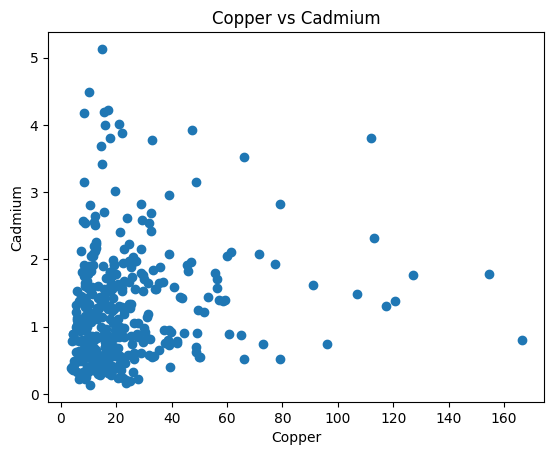

In [27]:
# Correlation matrix
corr = df.corr()

plt.scatter(df['Cu'], df['Cd'])
plt.xlabel('Copper')
plt.ylabel('Cadmium')
plt.title('Copper vs Cadmium')
plt.show()

Task 2

In [28]:
# Target (Y) and Features (X)
X = df.drop(columns=['Cd'])
y = df['Cd']

In [29]:
# Polynomial Features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [30]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

Task 3

In [31]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Models
lin_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0)


In [32]:

# Train models
lin_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [34]:
lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [35]:
# Predictions
y_pred_lin = lin_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# RMSE
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# R2 Score
r2_lin = r2_score(y_test, y_pred_lin)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results
print("Linear RMSE:", rmse_lin, "R2:", r2_lin)
print("Ridge RMSE:", rmse_ridge, "R2:", r2_ridge)
print("Lasso RMSE:", rmse_lasso, "R2:", r2_lasso)

Linear RMSE: 0.8328470808943294 R2: -0.06897541552737407
Ridge RMSE: 0.5436805249582448 R2: 0.5444618700451495
Lasso RMSE: 0.8087172166439488 R2: -0.007930435176925155


In [ ]:
# Coefficients
print("Linear Coefficients:", lin_model.coef_)
print("Ridge Coefficients:", ridge_model.coef_)
print("Lasso Coefficients:", lasso_model.coef_)

Linear Coefficients: [-1.52636106e-01  4.35489373e-01  4.17901890e-02 -6.66587332e-02
  1.05519664e-02  5.58329578e-02  8.56176263e-02  5.69267814e-02
 -6.57678219e-02 -8.22630949e-03 -8.51524800e-02  8.86594978e-01
 -6.25355180e-01 -5.36648895e-01 -2.86524139e-01  2.88164528e-01
  3.81827806e-01 -1.16107267e-01  8.79875674e-02  2.75238893e-01
 -2.45799755e-01 -1.04820650e-01  2.14590718e-02 -2.28898257e-01
  1.27735788e-01  4.49287726e-02  6.22322894e-02 -1.57998299e-01
 -2.29803299e-01 -7.99946738e-01 -7.98999718e-01  1.96001005e+00
  5.32211123e-01 -2.75045908e-01 -2.25703242e-01 -4.22650387e-03
  2.17299432e-01  1.09882955e-01  2.77746390e-01  9.48857911e-03
  2.15910942e-01  2.55054165e-02 -9.88379853e-03  1.85739321e-01
 -6.56017301e-01  8.67833029e-01  5.52332928e-01 -4.14582694e-01
 -7.47936820e-01 -3.38991789e-02  4.17901890e-02 -1.14838694e-15
  1.30451205e-15 -2.15105711e-15  2.77796239e-02  7.69157662e-03
  6.75088490e-02 -3.30806015e-03 -6.88338275e-15 -1.23014582e-01
 -4.

In [45]:
# Identify zero coefficients
lasso_zero_features = np.sum(lasso_model.coef_ == 0)
print("Number of features reduced to zero:", lasso_zero_features)

Number of features reduced to zero: 170


In this model Ridge perform Good because 

Linear Regression RMSE is Very High and R2 is also negative which is very bad 

Ridge Regreesion RMSE is 0.54 which is good and R2 is 0.54 which is also good 

And for Lasso Regression RMSE is 0.81 and R2 is -0.008 which is slightly better than Linear but still poor.